# Preprocessing

#### Imports

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from scipy.signal import savgol_filter

In [73]:
df = pd.read_csv("tobacco-nir-all.csv")

In [74]:
#  New dataframe with 4 targets instead of 6

df["Country4"] = df["Country"].replace({
    "Brazil":    "Brazil",
    "USA":       "USA",
    "Zimbabwe":  "Zimbabwe",
    "Argentina": "Argentina/Tanzania/Zambia",
    "Tanzania":  "Argentina/Tanzania/Zambia",
    "Zambia":    "Argentina/Tanzania/Zambia",
})

# 2) Identify metadata and spectral columns
meta_cols = ['Sample ID', 'Planting year', 'Country', 'Country4']
spec_cols = [c for c in df.columns if c not in meta_cols]

# 3) Feature matrix X and labels y (4-klasser)
X = df[spec_cols].values
y = df['Country4'].values

In [75]:
print("Number of samples from Argentina/Tanzania/Zambia: ", df[df["Country4"] == "Argentina/Tanzania/Zambia"].shape[0])
print("Number of samples from Brazil: ", df[df["Country4"] == "Brazil"].shape[0])
print("Number of samples from USA: ", df[df["Country4"] == "USA"].shape[0])
print("Number of samples from Zimbabwe: ", df[df["Country4"] == "Zimbabwe"].shape[0])

Number of samples from Argentina/Tanzania/Zambia:  38
Number of samples from Brazil:  136
Number of samples from USA:  45
Number of samples from Zimbabwe:  128


### For consistent plotting

In [76]:
COUNTRY_COLORS = {
    "Argentina/Tanzania/Zambia": "#bcbd22",
    "Brazil":    "#2ca02c",
    "USA":       "#e377c2",
    "Zimbabwe":  "#17becf",    
    "Other":     "#b0b0b0"
}

YEAR_COLORS = {
    2018: "#1f77b4",  
    2019: "#2ca02c",  
    2020: "#9467bd",  
    2021: "#e377c2",  
    2022: "#bcbd22",  
    "Other": "#b0b0b0"
}


plt.style.use("dark_background")

### Preprocessing

- SNV (Standard Normal Variate) 
- MSC (Multiplicative Scatter Correction)
- SG1 (Savitzky–Golay 1. derivative)
- SG2 (Savitzky–Golay 2. derivative)
- SG1 and SG2 with SNV
- Mean centering

In [77]:
# SNV (Standard Normal Variate)
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1, ddof=1, keepdims=True)
    return (X - mean) / std

X_snv = snv(X)

# MSC (Multiplicative Scatter Correction)
def msc(X):
    # Reference spectrum = mean spectrum
    ref = X.mean(axis=0, keepdims=True)
    X_corr = np.zeros_like(X)
    for i, x in enumerate(X):
        # Linear regression: x ≈ a * ref + b
        A = np.vstack([ref.ravel(), np.ones(ref.size)]).T
        a, b = np.linalg.lstsq(A, x, rcond=None)[0]
        X_corr[i, :] = (x - b) / a
    return X_corr

X_msc = msc(X)

# SG 1st derivative
# axis=1 since wavenumbers are along the columns
X_sg1 = savgol_filter(X, window_length=17, polyorder=2, deriv=1, axis=1)

# SG 2nd derivative
# axis=1 since wavenumbers are along the columns
X_sg2 = savgol_filter(X, window_length=17, polyorder=2, deriv=2, axis=1)

# Combination: 1st and 2nd derivative + SNV
X_sg1_snv = snv(X_sg1)
X_sg2_snv = snv(X_sg2)

In [78]:
def mean_center(X):
    return X - X.mean(axis=0)

X_raw_mc = mean_center(X)
X_snv_mc = mean_center(X_snv)
X_msc_mc = mean_center(X_msc)
X_sg1_snv_mc = mean_center(X_sg1_snv)
X_sg2_snv_mc = mean_center(X_sg2_snv)

## PCA of the different datasets 

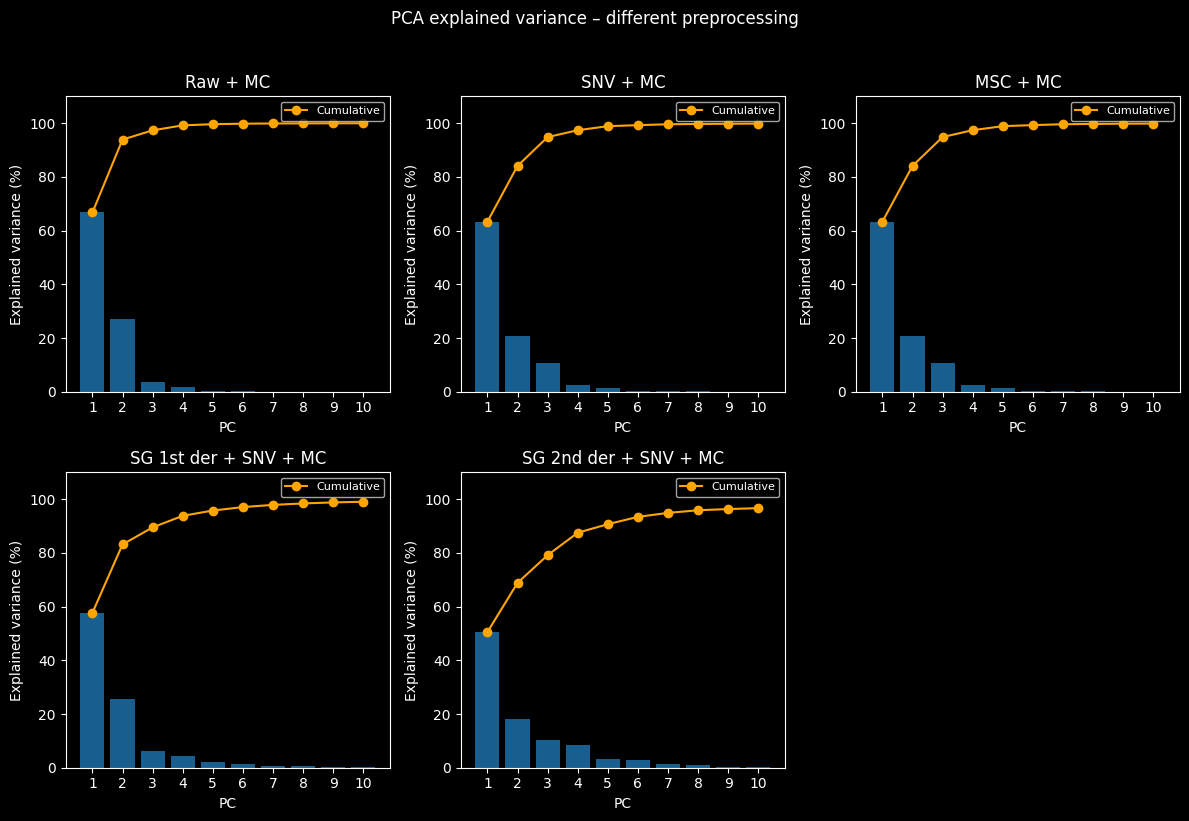

In [86]:
X_list = [
    X_raw_mc,
    X_snv_mc,
    X_msc_mc,
    X_sg1_snv_mc,
    X_sg2_snv_mc,
]

titles = [
    "Raw + MC",
    "SNV + MC",
    "MSC + MC",
    "SG 1st der + SNV + MC",
    "SG 2nd der + SNV + MC",
]

# Compare explained variance across preprocessing methods in a 2×3 grid
n_rows, n_cols = 2, 3
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 4 * n_rows),
    sharex=False, sharey=False,
)
axes = axes.ravel()

n_components = 10  # number of PCs to inspect

for i, (X_var, title) in enumerate(zip(X_list, titles)):
    ax = axes[i]

    pca = PCA(n_components=n_components)
    pca.fit(X_var)

    explained_var = pca.explained_variance_ratio_
    pcs = np.arange(1, len(explained_var) + 1)

    # Bars: explained variance per PC
    ax.bar(pcs, explained_var * 100, color="#1f77b4", alpha=0.8)

    # Line: cumulative explained variance
    ax.plot(
        pcs,
        np.cumsum(explained_var) * 100,
        marker="o",
        color="orange",
        label="Cumulative",
    )

    ax.set_title(title)
    ax.set_xlabel("PC")
    ax.set_ylabel("Explained variance (%)")
    ax.set_xticks(pcs)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=8)

# Remove unused panel(s) if we have fewer datasets than grid cells
if len(X_list) < len(axes):
    for j in range(len(X_list), len(axes)):
        fig.delaxes(axes[j])

fig.suptitle("PCA explained variance – different preprocessing", y=1.02)
plt.tight_layout()
plt.show()


#### All preprocessed datasets

In [80]:
datasets = [
    ("Raw + MC",            X_raw_mc),
    ("SNV + MC",            X_snv_mc),
    ("MSC + MC",            X_msc_mc),
    ("SG 1st der + SNV + MC", X_sg1_snv_mc),
    ("SG 2nd der + SNV + MC", X_sg2_snv_mc),
]

#### Explained variance of each 10 components for all datasets

In [81]:
def pca_variance_markdown(explained_var, n_components=None):
    pc_indices = np.arange(1, len(explained_var) + 1)
    explained_pct = explained_var * 100
    cum_explained_pct = np.cumsum(explained_var) * 100

    if n_components is None:
        n_components = len(explained_var)

    lines = []
    lines.append("| PC | Explained variance (%) | Cumulative (%) |")
    lines.append("|----|------------------------|----------------|")
    for i in range(n_components):
        lines.append(
            f"| {pc_indices[i]} | {explained_pct[i]:5.2f} | {cum_explained_pct[i]:5.2f} |"
        )
    return "\n".join(lines)

n_components = 10   
n_print = 5         

for name, X_var in datasets:
    print(f"\n### {name}")
    pca = PCA(n_components=n_components)
    pca.fit(X_var)
    explained_var = pca.explained_variance_ratio_

    md_table = pca_variance_markdown(explained_var, n_components=n_print)
    print(md_table)




### Raw + MC
| PC | Explained variance (%) | Cumulative (%) |
|----|------------------------|----------------|
| 1 | 66.76 | 66.76 |
| 2 | 27.13 | 93.89 |
| 3 |  3.45 | 97.34 |
| 4 |  1.86 | 99.19 |
| 5 |  0.43 | 99.63 |

### SNV + MC
| PC | Explained variance (%) | Cumulative (%) |
|----|------------------------|----------------|
| 1 | 63.33 | 63.33 |
| 2 | 20.77 | 84.09 |
| 3 | 10.73 | 94.83 |
| 4 |  2.55 | 97.38 |
| 5 |  1.51 | 98.89 |

### MSC + MC
| PC | Explained variance (%) | Cumulative (%) |
|----|------------------------|----------------|
| 1 | 63.34 | 63.34 |
| 2 | 20.76 | 84.11 |
| 3 | 10.73 | 94.84 |
| 4 |  2.55 | 97.39 |
| 5 |  1.51 | 98.90 |

### SG 1st der + SNV + MC
| PC | Explained variance (%) | Cumulative (%) |
|----|------------------------|----------------|
| 1 | 57.70 | 57.70 |
| 2 | 25.44 | 83.14 |
| 3 |  6.36 | 89.50 |
| 4 |  4.30 | 93.80 |
| 5 |  1.97 | 95.77 |

### SG 2nd der + SNV + MC
| PC | Explained variance (%) | Cumulative (%) |
|----|-----------------

## PCA score plots

In [82]:
countries = np.unique(y)

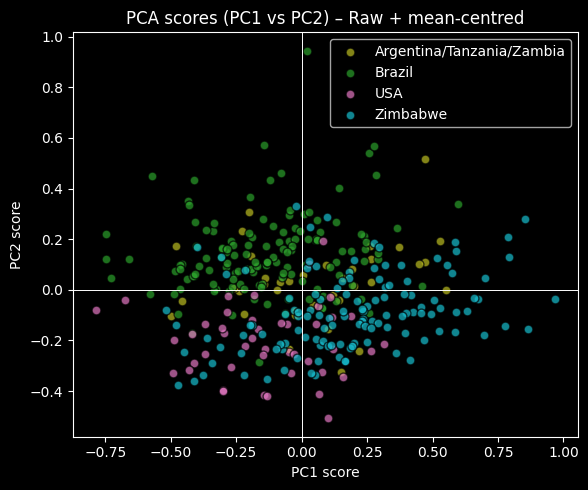

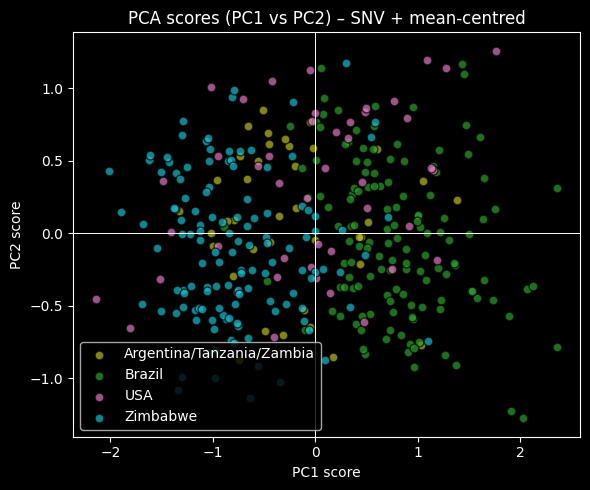

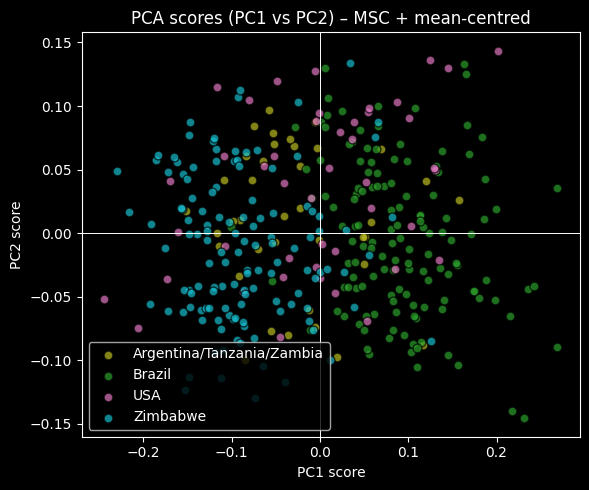

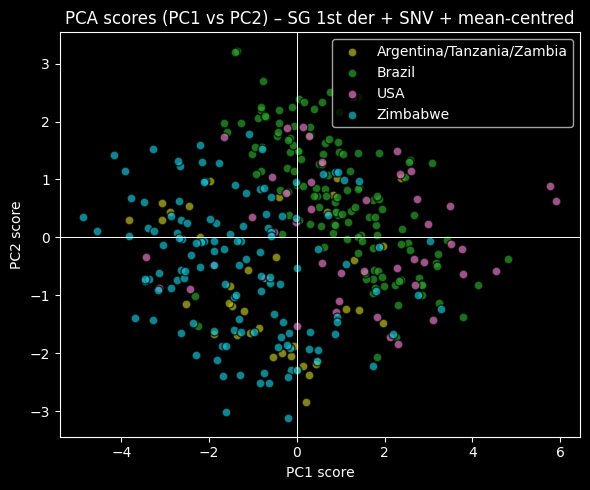

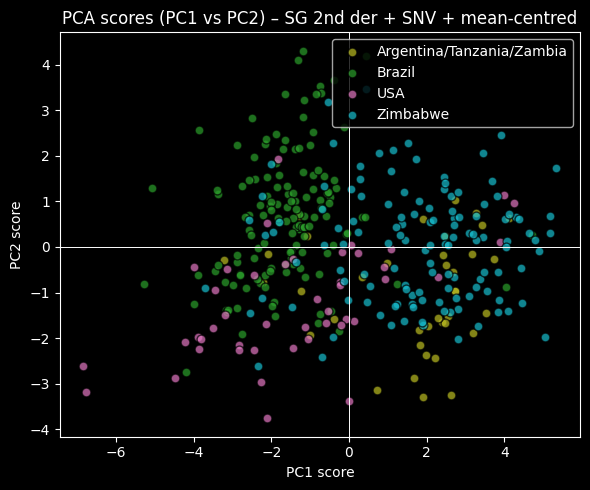

In [83]:
def plot_pca_scores(T, y, countries, title):
    pc1 = T[:, 0]
    pc2 = T[:, 1]
    
    plt.figure(figsize=(6, 5))
    for country in countries:
        idx = (y == country)
        plt.scatter(
            pc1[idx], pc2[idx],
            color=COUNTRY_COLORS.get(country, COUNTRY_COLORS["Other"]),
            label=country, alpha=0.7, edgecolor='k', s=40
        )

    plt.xlabel("PC1 score")
    plt.ylabel("PC2 score")
    plt.title(title)
    plt.axhline(0, color='white', linewidth=0.7)
    plt.axvline(0, color='white', linewidth=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

pca_raw = PCA(n_components=2)
T_raw = pca_raw.fit_transform(X_raw_mc)
plot_pca_scores(T_raw, y, countries, "PCA scores (PC1 vs PC2) – Raw + mean-centred")

pca_snv = PCA(n_components=2)
T_snv = pca_snv.fit_transform(X_snv_mc)
plot_pca_scores(T_snv, y, countries, "PCA scores (PC1 vs PC2) – SNV + mean-centred")

pca_msc = PCA(n_components=2)
T_msc = pca_msc.fit_transform(X_msc_mc)
plot_pca_scores(T_msc, y, countries, "PCA scores (PC1 vs PC2) – MSC + mean-centred")

pca_sg1 = PCA(n_components=2)
T_sg1 = pca_sg1.fit_transform(X_sg1_snv_mc)
plot_pca_scores(T_sg1, y, countries, "PCA scores (PC1 vs PC2) – SG 1st der + SNV + mean-centred")

pca_sg2 = PCA(n_components=2)
T_sg2 = pca_sg2.fit_transform(X_sg2_snv_mc)
plot_pca_scores(T_sg2, y, countries, "PCA scores (PC1 vs PC2) – SG 2nd der + SNV + mean-centred")

### kNN (k-Nearest Neigbhours) to identify most accurate clusters

In [84]:
datasets = [
    ("Raw + MC",              X_raw_mc),
    ("SNV + MC",              X_snv_mc),
    ("MSC + MC",              X_msc_mc),
    ("SG 1st der + SNV + MC", X_sg1_snv_mc),
    ("SG 2nd der + SNV + MC", X_sg2_snv_mc),
]

# Hyperparameters
components_grid = [2, 3, 5, 10]          # number of principal components
k_grid          = [3, 5, 7, 11, 15]      # k in kNN
cv_folds        = 5                      # 5-fold stratified cross-validation

rows = []

for name, X_var in datasets:
    for n_components in components_grid:
        # PCA -> take the first n_components
        pca = PCA(n_components=n_components)
        T_var = pca.fit_transform(X_var)

        for k_neighbors in k_grid:
            knn = KNeighborsClassifier(n_neighbors=k_neighbors)
            scores = cross_val_score(
                knn, T_var, y, cv=cv_folds, scoring="accuracy"
            )
            rows.append({
                "Dataset": name,
                "n_components": n_components,
                "k": k_neighbors,
                "mean_accuracy": scores.mean(),
                "std_accuracy": scores.std()
            })

# Collect results in a DataFrame
results_df = pd.DataFrame(rows)

# Find the best combination per dataset
best_per_dataset = (
    results_df
    .sort_values(["Dataset", "mean_accuracy"], ascending=[True, False])
    .groupby("Dataset")
    .head(1)
)

print("All hyperparameter combinations:\n")
print(results_df.to_string(index=False, float_format="%.3f"))

print("\nBest combination per dataset:\n")
print(best_per_dataset.to_string(index=False, float_format="%.3f"))


All hyperparameter combinations:

              Dataset  n_components  k  mean_accuracy  std_accuracy
             Raw + MC             2  3          0.559         0.038
             Raw + MC             2  5          0.594         0.037
             Raw + MC             2  7          0.646         0.024
             Raw + MC             2 11          0.663         0.054
             Raw + MC             2 15          0.646         0.056
             Raw + MC             3  3          0.692         0.043
             Raw + MC             3  5          0.703         0.037
             Raw + MC             3  7          0.717         0.032
             Raw + MC             3 11          0.720         0.036
             Raw + MC             3 15          0.709         0.041
             Raw + MC             5  3          0.741         0.034
             Raw + MC             5  5          0.749         0.036
             Raw + MC             5  7          0.749         0.036
             R

To quantify how well each preprocessing method separated the four origin classes in the PCA space, we trained a kNN classifier on the first two principal components and estimated the classification accuracy using 5-fold cross-validation. 

Among the tested variants (Raw + MC, SNV + MC, MSC + MC, SG 1st derivative + SNV + MC, SG 2nd derivative + SNV + MC), SG 1st derivative + SNV + MC, SG 2nd derivative achieved the highestaccuracy of 0.844 and 0.847 %.

## Conlusion regarding results of preprocessed data

Based on the kNN classification results in PCA space and visual inspection of the score plots, we decided to proceed with the combination of Savitzky–Golay second derivative (SG2), SNV and mean centering. All subsequent modelling is therefore based on the SG2 + SNV + mean‑centred data, while the mean‑centred raw spectra will be used as a baseline for comparison.

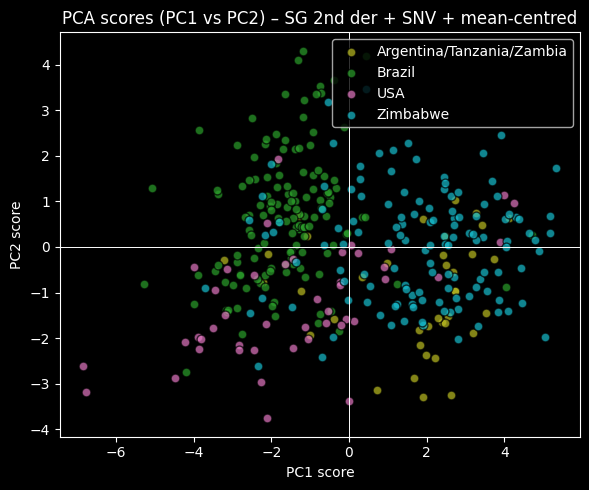

In [85]:
pca_sg2 = PCA(n_components=2)
T_sg2 = pca_sg2.fit_transform(X_sg2_snv_mc)
plot_pca_scores(T_sg2, y, countries, "PCA scores (PC1 vs PC2) – SG 2nd der + SNV + mean-centred")